<div align="center">

# Sliding window

</div>

# 1. Sliding window

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py

In [2]:
def load_h5(path):
    with h5py.File(path, "r") as f:
        signals = f["signals"][:]
        fs = f["sampling_rate"][()]
        ch_names = f["channel_names"][:]
        intervals = f["seizure_intervals"][:] if "seizure_intervals" in f else np.array([])
        
    ch_names = [
        c.decode() if isinstance(c, (bytes, bytearray)) else c
        for c in ch_names
    ]
    return signals, fs, ch_names, intervals

In [5]:
path = "../Dataset_preprocessed/chb01_01.h5"
signals, fs, ch_names, intervals = load_h5(path)

print(signals.shape)
print(fs)
print(ch_names)
print(intervals)

(22, 921600)
256.0
['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'FP2-F8', 'F8-T8', 'T8-P8', 'P8-O2', 'FZ-CZ', 'CZ-PZ', 'P7-T7', 'T7-FT9', 'FT9-FT10', 'FT10-T8']
[]


In [4]:
signals

array([[-4.44536539e-07,  1.43219266e-04,  1.42874342e-04, ...,
        -3.14793433e-05, -2.38507819e-05, -7.01492752e-07],
       [-9.02617103e-07,  1.00773868e-04,  1.01260062e-04, ...,
        -6.01624879e-06, -1.80193126e-06,  3.64423443e-07],
       [ 1.99968838e-07,  4.25081016e-05,  4.22749727e-05, ...,
         1.51334343e-05,  1.12202206e-05,  6.06488697e-07],
       ...,
       [-4.24840493e-07,  2.58363259e-04,  2.59030145e-04, ...,
         3.07609916e-05,  1.46870125e-05,  5.65574510e-07],
       [ 1.03331082e-07, -9.28606969e-05, -9.25398635e-05, ...,
         6.02279488e-06,  3.21211974e-06, -4.79332236e-08],
       [ 2.84050721e-08, -4.43400168e-05, -4.36991031e-05, ...,
        -8.71603152e-06, -3.18360662e-06,  1.79590828e-07]], dtype=float32)

In [11]:
import numpy as np
import h5py


def load_h5(path):
    with h5py.File(path, "r") as f:
        signals = f["signals"][:]
        fs = f["sampling_rate"][()]
        ch_names = f["channel_names"][:]
        intervals = (
            f["seizure_intervals"][:]
            if "seizure_intervals" in f
            else np.array([])
        )

    ch_names = [
        c.decode() if isinstance(c, (bytes, bytearray)) else c
        for c in ch_names
    ]

    return signals, fs, ch_names, intervals


def compute_overlap(window_start, window_end, seizure_start, seizure_end):
    """
    Compute overlap duration between two intervals in seconds.
    """
    overlap_start = max(window_start, seizure_start)
    overlap_end = min(window_end, seizure_end)

    return max(0, overlap_end - overlap_start)


def create_windows(
    signals,
    fs,
    seizure_intervals,
    window_sec=10,
    overlap=0.75,
    ictal_threshold=0.60
):
    """
    Parameters
    ----------
    signals : np.ndarray
        Shape: (n_channels, n_samples)

    seizure_intervals : np.ndarray
        Shape: (n_seizures, 2)
        Times in seconds

    Returns
    -------
    windows : np.ndarray
        Shape: (n_windows, n_channels, window_samples)

    labels : np.ndarray
        1 = ictal
        0 = interictal
    """

    n_channels, n_samples = signals.shape

    window_samples = int(window_sec * fs)
    step_samples = int(window_samples * (1 - overlap))

    windows = []
    labels = []

    for start_sample in range(
        0,
        n_samples - window_samples + 1,
        step_samples
    ):

        end_sample = start_sample + window_samples

        # Extract window
        window = signals[:, start_sample:end_sample]

        # Demean each channel independently
        window = window - window.mean(axis=1, keepdims=True)

        # Convert sample indices to seconds
        window_start_sec = start_sample / fs
        window_end_sec = end_sample / fs

        # Compute seizure overlap
        max_overlap_ratio = 0.0

        for seizure_start, seizure_end in seizure_intervals:

            overlap_sec = compute_overlap(
                window_start_sec,
                window_end_sec,
                seizure_start,
                seizure_end
            )

            overlap_ratio = overlap_sec / window_sec

            max_overlap_ratio = max(
                max_overlap_ratio,
                overlap_ratio
            )

        # Label assignment
        label = 1 if max_overlap_ratio >= ictal_threshold else 0

        windows.append(window)
        labels.append(label)

    windows = np.array(windows)
    labels = np.array(labels)

    return windows, labels

In [26]:
signals, fs, ch_names, intervals = load_h5(
    "../Dataset_hdf5_filtered_clean/chb01/chb01_01.h5"
)

windows, labels = create_windows(
    signals,
    fs,
    intervals,
)

print("Windows shape:", windows.shape)
print("Labels shape:", labels.shape)

print("Example window shape:", windows[0].shape)
print("Unique labels:", np.unique(labels, return_counts=True))

Windows shape: (1437, 22, 2560)
Labels shape: (1437,)
Example window shape: (22, 2560)
Unique labels: (array([0]), array([1437], dtype=int64))


In [24]:
labels

array([0, 0, 0, ..., 0, 0, 0])

# 2. VAR Order

In [21]:
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.vector_ar.var_model import VAR


def select_var_order(
    windows,
    labels,
    p_range=range(1, 15),
    n_samples=500,
    random_state=42
):
    """
    Parameters
    ----------
    windows : np.ndarray
        Shape: (n_windows, n_channels, n_samples)

    labels : np.ndarray
        0 = interictal
        1 = ictal

    Returns
    -------
    best_p : int
    mean_aic : list
    """

    rng = np.random.default_rng(random_state)

    # Keep only interictal windows
    interictal_windows = windows[labels == 0]

    print("Available interictal windows:",
          len(interictal_windows))

    # Random subset
    idx = rng.choice(
        len(interictal_windows),
        size=min(n_samples, len(interictal_windows)),
        replace=False
    )

    subset = interictal_windows[idx]

    mean_aic = []

    for p in p_range:

        aics = []

        print(f"Testing p = {p}")

        for w in subset:

            # VAR expects shape:
            # (timepoints, variables)

            data = w.T

            try:
                model = VAR(data)
                result = model.fit(p)

                aics.append(result.aic)

            except Exception:
                continue

        mean_score = np.mean(aics)

        mean_aic.append(mean_score)

        print(f"Mean AIC: {mean_score:.4f}")

    # Best order
    best_p = p_range[np.argmin(mean_aic)]

    return best_p, mean_aic

In [10]:
import os
import numpy as np

all_windows = []
all_labels = []

root = "../Dataset_hdf5_filtered_clean"

for subdir, _, files in os.walk(root):

    for file in files:

        if file.endswith(".h5"):

            path = os.path.join(subdir, file)

            print("Processing:", path)

            # Load file
            signals, fs, ch_names, intervals = load_h5(path)

            # Create windows
            windows, labels = create_windows(
                signals,
                fs,
                intervals
            )

            all_windows.append(windows)
            all_labels.append(labels)

# Combine all files
all_windows = np.concatenate(all_windows, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

print("Final windows shape:", all_windows.shape)
print("Final labels shape:", all_labels.shape)

Processing: ../Dataset_hdf5_filtered_clean\chb01\chb01_01.h5
Processing: ../Dataset_hdf5_filtered_clean\chb01\chb01_02.h5
Processing: ../Dataset_hdf5_filtered_clean\chb01\chb01_03.h5


KeyboardInterrupt: 

In [27]:
# Select random sample across ALL patients for order selection
best_p, mean_aic = select_var_order(
    windows_10sec,      # All windows from all patients
    labels,             # All corresponding labels
    p_range=range(1, 31),
    n_samples=500,      # Random 500 interictal windows
    random_state=42
)

NameError: name 'windows_10sec' is not defined

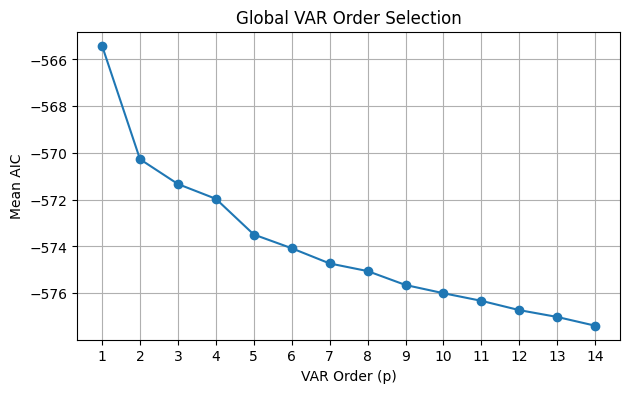

In [18]:
p_values = list(range(1, 15))

plt.figure(figsize=(7, 4))

plt.plot(p_values, mean_aic, marker='o')

plt.xlabel("VAR Order (p)")
plt.ylabel("Mean AIC")
plt.title("Global VAR Order Selection")

plt.xticks(p_values)

plt.grid(True)

plt.show()

## Other

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.vector_ar.var_model import VAR

def select_var_order(
    windows,
    labels,
    p_range=range(1, 31),  # Increased to 31
    n_samples=500,
    random_state=42
):
    """
    Select optimal VAR order using AIC criterion.
    
    Parameters
    ----------
    windows : np.ndarray
        Shape: (n_windows, n_channels, n_samples)
    labels : np.ndarray
        0 = interictal, 1 = ictal
    p_range : range
        Range of model orders to test
    n_samples : int
        Number of random windows to sample
    random_state : int
        Random seed for reproducibility
    
    Returns
    -------
    best_p : int
        Optimal model order
    mean_aic : list
        Mean AIC values for each order
    """
    
    rng = np.random.default_rng(random_state)
    
    # Keep only interictal windows
    interictal_windows = windows[labels == 0]
    
    print(f"Available interictal windows: {len(interictal_windows)}")
    
    # Random subset
    idx = rng.choice(
        len(interictal_windows),
        size=min(n_samples, len(interictal_windows)),
        replace=False
    )
    
    subset = interictal_windows[idx]
    
    mean_aic = []
    
    for p in p_range:
        aics = []
        failed = 0
        
        print(f"\nTesting p = {p}")
        
        for w in subset:
            # VAR expects shape: (timepoints, variables)
            data = w.T
            
            try:
                model = VAR(data)
                result = model.fit(p, ic=None)  # Disable automatic IC
                
                # Optional: check stability
                if result.is_stable():
                    aics.append(result.aic)
                else:
                    failed += 1
                    
            except Exception as e:
                failed += 1
                continue
        
        if len(aics) == 0:
            print(f"  WARNING: All models failed at p={p}")
            break
            
        mean_score = np.mean(aics)
        mean_aic.append(mean_score)
        
        print(f"  Mean AIC: {mean_score:.4f}")
        print(f"  Failed/Unstable: {failed}/{len(subset)} ({100*failed/len(subset):.1f}%)")
    
    # Best order (minimum AIC)
    best_p = p_range[np.argmin(mean_aic)]
    
    print(f"\n{'='*50}")
    print(f"Optimal order: p = {best_p}")
    print(f"AIC at optimal order: {mean_aic[best_p-1]:.4f}")
    print(f"{'='*50}")
    
    return best_p, mean_aic


# After running, plot the results
def plot_aic_curve(mean_aic, p_range, best_p):
    """Plot AIC vs model order"""
    plt.figure(figsize=(10, 6))
    plt.plot(list(p_range)[:len(mean_aic)], mean_aic, 'b-o', linewidth=2, markersize=6)
    plt.axvline(best_p, color='r', linestyle='--', label=f'Optimal p={best_p}')
    plt.xlabel('Model Order (p)', fontsize=12)
    plt.ylabel('Mean AIC', fontsize=12)
    plt.title('VAR Order Selection using AIC', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [29]:
# Run order selection
best_p, mean_aic = select_var_order(
    windows,
    labels,
    p_range=range(1, 31),
    n_samples=500
)

# Plot results
plot_aic_curve(mean_aic, range(1, 31), best_p)

# Use best_p for computing GC matrices
print(f"Use p={best_p} for Granger Causality computation")

Available interictal windows: 1437

Testing p = 1
  Mean AIC: -565.4104
  Failed/Unstable: 0/500 (0.0%)

Testing p = 2
  Mean AIC: -570.2685
  Failed/Unstable: 0/500 (0.0%)

Testing p = 3
  Mean AIC: -571.3457
  Failed/Unstable: 1/500 (0.2%)

Testing p = 4
  Mean AIC: -572.0190
  Failed/Unstable: 2/500 (0.4%)

Testing p = 5
  Mean AIC: -573.4601
  Failed/Unstable: 3/500 (0.6%)

Testing p = 6
  Mean AIC: -574.1178
  Failed/Unstable: 5/500 (1.0%)

Testing p = 7


KeyboardInterrupt: 